## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 10 · Decarbonisation scenarios for the planning study area (the wards)

The demand model is calibrated and validated for the whole authority at LSOA level (notebooks 06–09); the
planning questions are asked for the study area — here the ten urban wards of Guildford (28,663 dwellings),
where the rooftop-solar layer gives a PV potential per building and the network layer a substation cell per
building. Six scenarios, every dwelling evaluated on the calibrated archetype tier:

| scenario | what changes |
|---|---|
| U0 baseline | the benchmark-year stock as modelled |
| U1 electrification | every fossil-boiler dwelling to an air-source heat pump (space heat + hot water) |
| U2 envelope | the construction-eligible fabric package (cavity fill, solid-wall insulation, loft top-up, flat roof, glazing, draught proofing) |
| U3 envelope + electrification | fabric first, heat pumps sized on the improved fabric |
| U4 electrification + PV | U1 plus rooftop PV (cap 4 kWp, 45 % self-consumption) |
| U5 envelope + electrification + PV | everything |

Costs, incentives, prices, carbon factors and the grid trajectory are the files in `parameters/`
(2021 prices and factors held fixed; the 2026–2050 grid trajectory shown separately). Heat-pump households
heat differently from gas-boiler households: the annual heat of converted dwellings carries the field-trial
uplift (+8 %, Watson et al. 2021) and their hourly heat follows the trial profiles per outdoor-temperature
band (`ukubem.heatpumps`), with the hourly COP of Ruhnau et al. (2019) as used by Halloran (2024). Peaks are
the time-aligned sum of the dwelling profiles, no diversity factor. Section 7 quantifies the building-fabric
heating flexibility of the stock after Halloran (2024).

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import config as CFG
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
from ukubem.calibrate import (ArchetypeCalibrator, PHYS_BOUNDS, POST_FIXED, make_representatives, _stock_delivered, evaluate_on)
from ukubem import metrics as M, maps, profiles, measures, stock
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
theta = json.load(open(UBEM_OUT / "06_calibrated_theta.json")); phys, post = theta["physics"], theta["post"]
inputs0 = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
inputs, reps = make_representatives(inputs0)
folds = pd.read_csv(CV_FOLDS)
A_cal = UKGeometryAssumptions().with_(wall_u_scale=phys["wall_u_scale"], roof_u_scale=phys["roof_u_scale"], window_u_scale=phys["window_u_scale"],
                                      infil_scale=phys["infil_scale"], gains_scale=phys["gains_scale"], setpoint_offset_c=phys["setpoint_offset_c"],
                                      stochastic_setback_c=phys.get("setback_c", 12.0))
inten_cal = pd.read_csv(UBEM_OUT / "06_archetype_intensities_calibrated.csv", index_col=0)
stock_cal = pd.read_parquet(UBEM_OUT / "06_stock_calibrated.parquet")
print(f"{len(inputs):,} dwellings, {len(reps)} representatives, {folds['fold'].nunique()} spatial folds; calibrated physics {phys}")

57,300 dwellings, 102 representatives, 7 spatial folds; calibrated physics {'wall_u_scale': 1.0652602409167062, 'roof_u_scale': 1.1248578219743166, 'window_u_scale': 1.25, 'infil_scale': 0.8129959823081263, 'gains_scale': 0.8155295436843902, 'setpoint_offset_c': 1.0, 'setback_c': 15.691329877128062}


In [3]:
from ukubem import heatpumps as HP, flexibility as FX, params as PRM
L = maps.load_layers(CFG, town_only=True)
urban_ids = inputs.index[inputs["in_study_area"].astype(bool)]
urban = inputs.loc[urban_ids]
social_file = LSOA_SOCIAL_CSV
social = pd.read_csv(social_file).set_index("LSOA")[["imd_decile", "fuel_poor_pct"]] if social_file.exists() else None
print(f"{len(urban):,} dwellings in the study area; wards: {urban['ward'].value_counts().to_dict()}")
print("heating systems:", urban["systems_fam"].value_counts().to_dict()); print(f"with PV potential: {(urban['pv_kWp'] > 0).sum():,} ({urban['pv_kWp'].clip(upper=4).sum()/1e3:.1f} MWp at the 4 kWp cap, {urban['pv_kWp'].sum()/1e3:.1f} MWp technical)")

28,663 dwellings in the study area; wards: {'Castle': 4148, 'Stoke': 4018, 'Merrow': 3781, 'Burpham': 2827, 'Westborough': 2769, 'Bellfields & Slyfield': 2517, 'Onslow': 2500, 'Stoughton South': 2437, 'Stoughton North': 2298, 'St Nicolas': 1368}
heating systems: {'S.GasBoiler': 24082, 'S.ElecResistive': 1527, 'S.ElecStorage': 1508, 'S.GasCommunal': 1008, 'S.HeatPump': 362, 'S.OilBoiler': 105, 'S.LPGBoiler': 46, 'S.SolidFuel': 25}
with PV potential: 22,219 (69.4 MWp at the 4 kWp cap, 117.8 MWp technical)


## 1 · Scenarios at the archetype tier

Only the fabric package changes the heat need, so the representatives are re-simulated once
(`inten_fab`); electrification and PV act in the accounting (`ukubem.accounting`) and in the
economics. Every scenario is evaluated for the whole stock and reported for the study-area wards. Dwellings
converted to a heat pump carry the annual uplift of heat-pump households (`parameters/heat_pumps/operation.json`).

In [4]:
TARGET_SET = "planning"   # parameters/retrofit_measures/fabric_targets.json: "planning" (the code-style targets of the scenarios) or "register" (stricter register values)
inp_fab, applied_fab = measures.apply_package(inputs, measures.PACKAGES["U2_envelope"], TARGET_SET)
phys_fab = {**phys, "infil_scale": phys["infil_scale"] * measures.ASSUMPTIONS["targets"][TARGET_SET]["draught_ach_factor"]}
f_int = UBEM_OUT / "10_archetype_intensities_fabric.csv"
if f_int.exists():
    inten_fab = pd.read_csv(f_int, index_col=0)
else:
    cal = ArchetypeCalibrator(inputs=inp_fab, labels=labels, bench_lsoa=bench_lsoa, reps=reps, epw=str(EPW), pybui_src=str(PBE_SRC), n_real=3, seed=SEED, n_jobs=N_JOBS)
    t0 = time.time(); inten_fab = cal.simulate(phys_fab); inten_fab.to_csv(f_int); print(f"fabric-package representatives simulated in {(time.time()-t0)/60:.1f} min")
a_file = UBEM_OUT / "10_envelope_areas.parquet"
if a_file.exists():
    areas = pd.read_parquet(a_file)
else:
    t0 = time.time(); areas = measures.envelope_areas(urban); areas_fab = measures.envelope_areas(inp_fab.loc[urban_ids])
    areas = areas.join(areas_fab[["HTC_fabric_W_K", "H_ve_W_K"]].rename(columns=lambda c: c + "_fab")); areas.to_parquet(a_file); print(f"envelope areas in {(time.time()-t0)/60:.1f} min")
htc0 = areas["HTC_fabric_W_K"] + areas["H_ve_W_K"]; htc_fab = areas["HTC_fabric_W_K_fab"] + areas["H_ve_W_K_fab"]
print(f"fabric package: mean space-heat intensity of the representatives {inten_cal['Q_H_kWh_m2'].mean():.1f} -> {inten_fab['Q_H_kWh_m2'].mean():.1f} kWh/m2")

fabric package: mean space-heat intensity of the representatives 104.3 -> 52.8 kWh/m2


In [5]:
HPO = PRM.load("heat_pumps", "operation"); HP_UPLIFT = HPO["annual_heat_uplift_heat_pump_households"] if HPO["apply_uplift_in_scenarios"] else 1.0
print(f"annual space-heat uplift for dwellings converted to a heat pump: x{HP_UPLIFT:.2f} (Watson et al. 2021: heat-pump households heat longer)")
scen, econ_parts = {}, {}
for name, pkg in measures.PACKAGES.items():
    inp_s, applied = measures.apply_package(inputs, pkg, TARGET_SET)
    fabric = any(m in pkg for m in ("cavity_fill", "solid_wall_iwi", "loft_topup", "flat_roof", "glazing_upgrade", "draught_proofing"))
    converted = applied["ashp"].reindex(inp_s.index).fillna(False).astype(bool) if "ashp" in applied.columns else pd.Series(False, index=inp_s.index)
    hf = pd.Series(np.where(converted, HP_UPLIFT, 1.0), index=inp_s.index)
    st = _stock_delivered(inp_s, inten_fab if fabric else inten_cal, post, heat_factor=hf).set_index("dwelling_id")
    pv = measures.pv_terms(inp_s, applied["pv"])
    bc = measures.bills_and_carbon(st, pv)
    costs = measures.measure_costs(inp_s.loc[urban_ids], applied.loc[urban_ids], areas, (htc_fab if fabric else htc0))
    inc = measures.incentives(inp_s.loc[urban_ids], costs, social)
    s = st.join(bc).join(pv).join(inputs[["ward", "LSOA", "toid", "construction_sa", "accommodation_type", "tenure", "age_band_resolved", "in_study_area"]])
    s = s.join(costs).join(inc).join(applied.add_prefix("applied_"))
    scen[name] = s; s.loc[urban_ids].to_parquet(UBEM_OUT / f"10_scenario_{name}.parquet")
    u = s.loc[urban_ids]
    print(f"{name:22s} gas {u['delivered_gas_kWh'].sum()/1e6:6.1f} GWh  elec net {u['elec_net_kWh'].sum()/1e6:6.1f} GWh  PV {u['pv_generation_kWh'].sum()/1e6:5.1f} GWh  "
          f"carbon {u['carbon_kg'].sum()/1e6:6.1f} kt  bills £{u['bill_GBP'].sum()/1e6:5.1f}M  capex £{u['capex_gross_GBP'].sum()/1e6:5.0f}M gross / £{(u['capex_gross_GBP']-u['incentives_GBP']).sum()/1e6:5.0f}M net")
base = scen["U0_baseline"].loc[urban_ids]
rows = []
for name, s in scen.items():
    u = s.loc[urban_ids]
    for w, g in u.groupby("ward"):
        b = base.loc[g.index]
        e = measures.economics(b, g, g, g)
        rows.append({"ward": w, "scenario": name, "n_dwellings": len(g), "gas_GWh": g["delivered_gas_kWh"].sum() / 1e6, "elec_net_GWh": g["elec_net_kWh"].sum() / 1e6,
                     "pv_GWh": g["pv_generation_kWh"].sum() / 1e6, "pv_MWp": g["pv_kWp_installed"].sum() / 1e3, "carbon_kt": g["carbon_kg"].sum() / 1e6,
                     "carbon_saving_pct": 100 * (1 - g["carbon_kg"].sum() / b["carbon_kg"].sum()), "bills_MGBP": g["bill_GBP"].sum() / 1e6,
                     "bill_change_pct": 100 * (g["bill_GBP"].sum() / b["bill_GBP"].sum() - 1), "capex_gross_MGBP": g["capex_gross_GBP"].sum() / 1e6,
                     "capex_net_MGBP": (g["capex_gross_GBP"] - g["incentives_GBP"]).sum() / 1e6, "hp_dwellings": int((g["ashp_kW"] > 0).sum()), "hp_MW": g["ashp_kW"].sum() / 1e3,
                     "median_payback_yr": float(np.median(e.loc[e["net_upfront_GBP"] > 0, "payback_years"].replace(np.inf, np.nan).dropna())) if (e["net_upfront_GBP"] > 0).any() else np.nan,
                     "share_bills_fall_pct": 100 * float((e["bill_saving_GBP"] > 0).mean())})
by_ward = pd.DataFrame(rows); by_ward.to_csv(UBEM_OUT / "10_scenario_by_ward.csv", index=False)
summary = by_ward.groupby("scenario").agg(n_dwellings=("n_dwellings", "sum"), gas_GWh=("gas_GWh", "sum"), elec_net_GWh=("elec_net_GWh", "sum"), pv_GWh=("pv_GWh", "sum"),
                                          carbon_kt=("carbon_kt", "sum"), bills_MGBP=("bills_MGBP", "sum"), capex_gross_MGBP=("capex_gross_MGBP", "sum"), capex_net_MGBP=("capex_net_MGBP", "sum"), hp_MW=("hp_MW", "sum")).reindex(list(measures.PACKAGES))
summary["carbon_saving_pct"] = 100 * (1 - summary["carbon_kt"] / summary.loc["U0_baseline", "carbon_kt"]); summary["bill_change_pct"] = 100 * (summary["bills_MGBP"] / summary.loc["U0_baseline", "bills_MGBP"] - 1)
summary.round(1).to_csv(UBEM_OUT / "10_scenario_summary.csv")
summary.round(1)

annual space-heat uplift for dwellings converted to a heat pump: x1.08 (Watson et al. 2021: heat-pump households heat longer)


U0_baseline            gas  367.0 GWh  elec net  121.5 GWh  PV   0.0 GWh  carbon   94.0 kt  bills £ 39.9M  capex £    0M gross / £    0M net


U1_electrification     gas    9.4 GWh  elec net  241.0 GWh  PV   0.0 GWh  carbon   52.9 kt  bills £ 49.3M  capex £  266M gross / £  110M net


U2_envelope            gas  242.9 GWh  elec net  117.0 GWh  PV   0.0 GWh  carbon   69.9 kt  bills £ 33.8M  capex £   92M gross / £   70M net


U3_envelope_elec       gas    8.5 GWh  elec net  197.0 GWh  PV   0.0 GWh  carbon   43.4 kt  bills £ 40.3M  capex £  332M gross / £  154M net


U4_elec_pv             gas    9.4 GWh  elec net  207.1 GWh  PV  75.2 GWh  carbon   45.7 kt  bills £ 39.3M  capex £  388M gross / £  232M net


U5_envelope_elec_pv    gas    8.5 GWh  elec net  163.2 GWh  PV  75.2 GWh  carbon   36.2 kt  bills £ 30.4M  capex £  455M gross / £  276M net


,n_dwellings,gas_GWh,elec_net_GWh,pv_GWh,carbon_kt,bills_MGBP,capex_gross_MGBP,capex_net_MGBP,hp_MW,carbon_saving_pct,bill_change_pct
scenario,,,,,,,,,,,
U0_baseline,28663,367.0,121.5,0.0,94.0,39.9,0.0,0.0,0.0,0.0,0.0
U1_electrification,28663,9.4,241.0,0.0,52.9,49.3,266.2,109.9,199.1,43.7,23.5
U2_envelope,28663,242.9,117.0,0.0,69.9,33.8,92.1,70.2,0.0,25.6,-15.2
U3_envelope_elec,28663,8.5,197.0,0.0,43.4,40.3,332.4,154.2,168.6,53.9,1.1
U4_elec_pv,28663,9.4,207.1,75.2,45.7,39.3,388.3,231.9,199.1,51.4,-1.5
U5_envelope_elec_pv,28663,8.5,163.2,75.2,36.2,30.4,454.5,276.3,168.6,61.5,-23.9


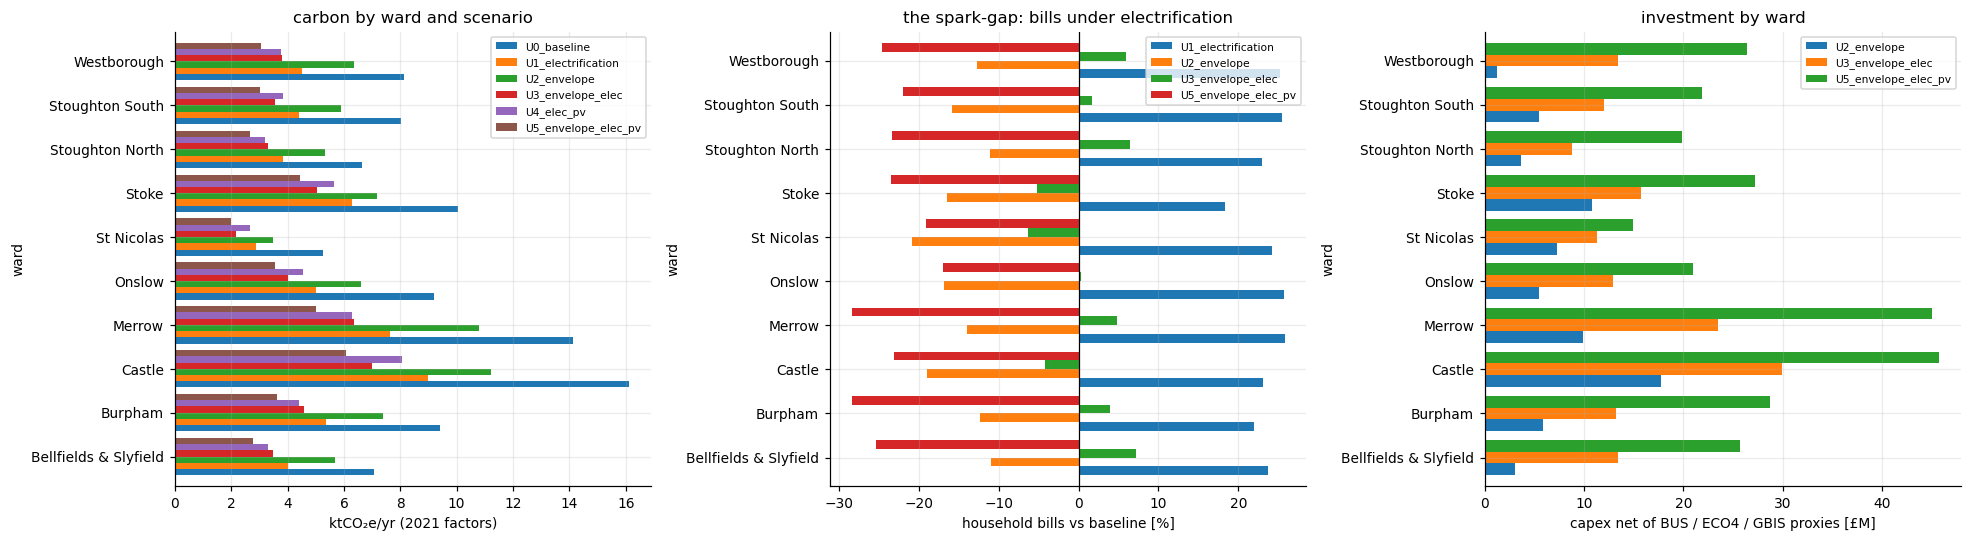

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
piv = by_ward.pivot(index="ward", columns="scenario", values="carbon_kt")[list(measures.PACKAGES)]
piv.plot.barh(ax=axes[0], width=0.85); axes[0].set_xlabel("ktCO₂e/yr (2021 factors)"); axes[0].set_title("carbon by ward and scenario"); axes[0].legend(fontsize=7)
piv2 = by_ward.pivot(index="ward", columns="scenario", values="bill_change_pct")[["U1_electrification", "U2_envelope", "U3_envelope_elec", "U5_envelope_elec_pv"]]
piv2.plot.barh(ax=axes[1], width=0.8); axes[1].axvline(0, color="k", lw=0.8); axes[1].set_xlabel("household bills vs baseline [%]"); axes[1].set_title("the spark-gap: bills under electrification"); axes[1].legend(fontsize=7)
piv3 = by_ward.pivot(index="ward", columns="scenario", values="capex_net_MGBP")[["U2_envelope", "U3_envelope_elec", "U5_envelope_elec_pv"]]
piv3.plot.barh(ax=axes[2], width=0.8); axes[2].set_xlabel("capex net of BUS / ECO4 / GBIS proxies [£M]"); axes[2].set_title("investment by ward"); axes[2].legend(fontsize=7)
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_scenarios_by_ward.png", bbox_inches="tight"); plt.show()

## 2 · Maps: every footprint of the study area

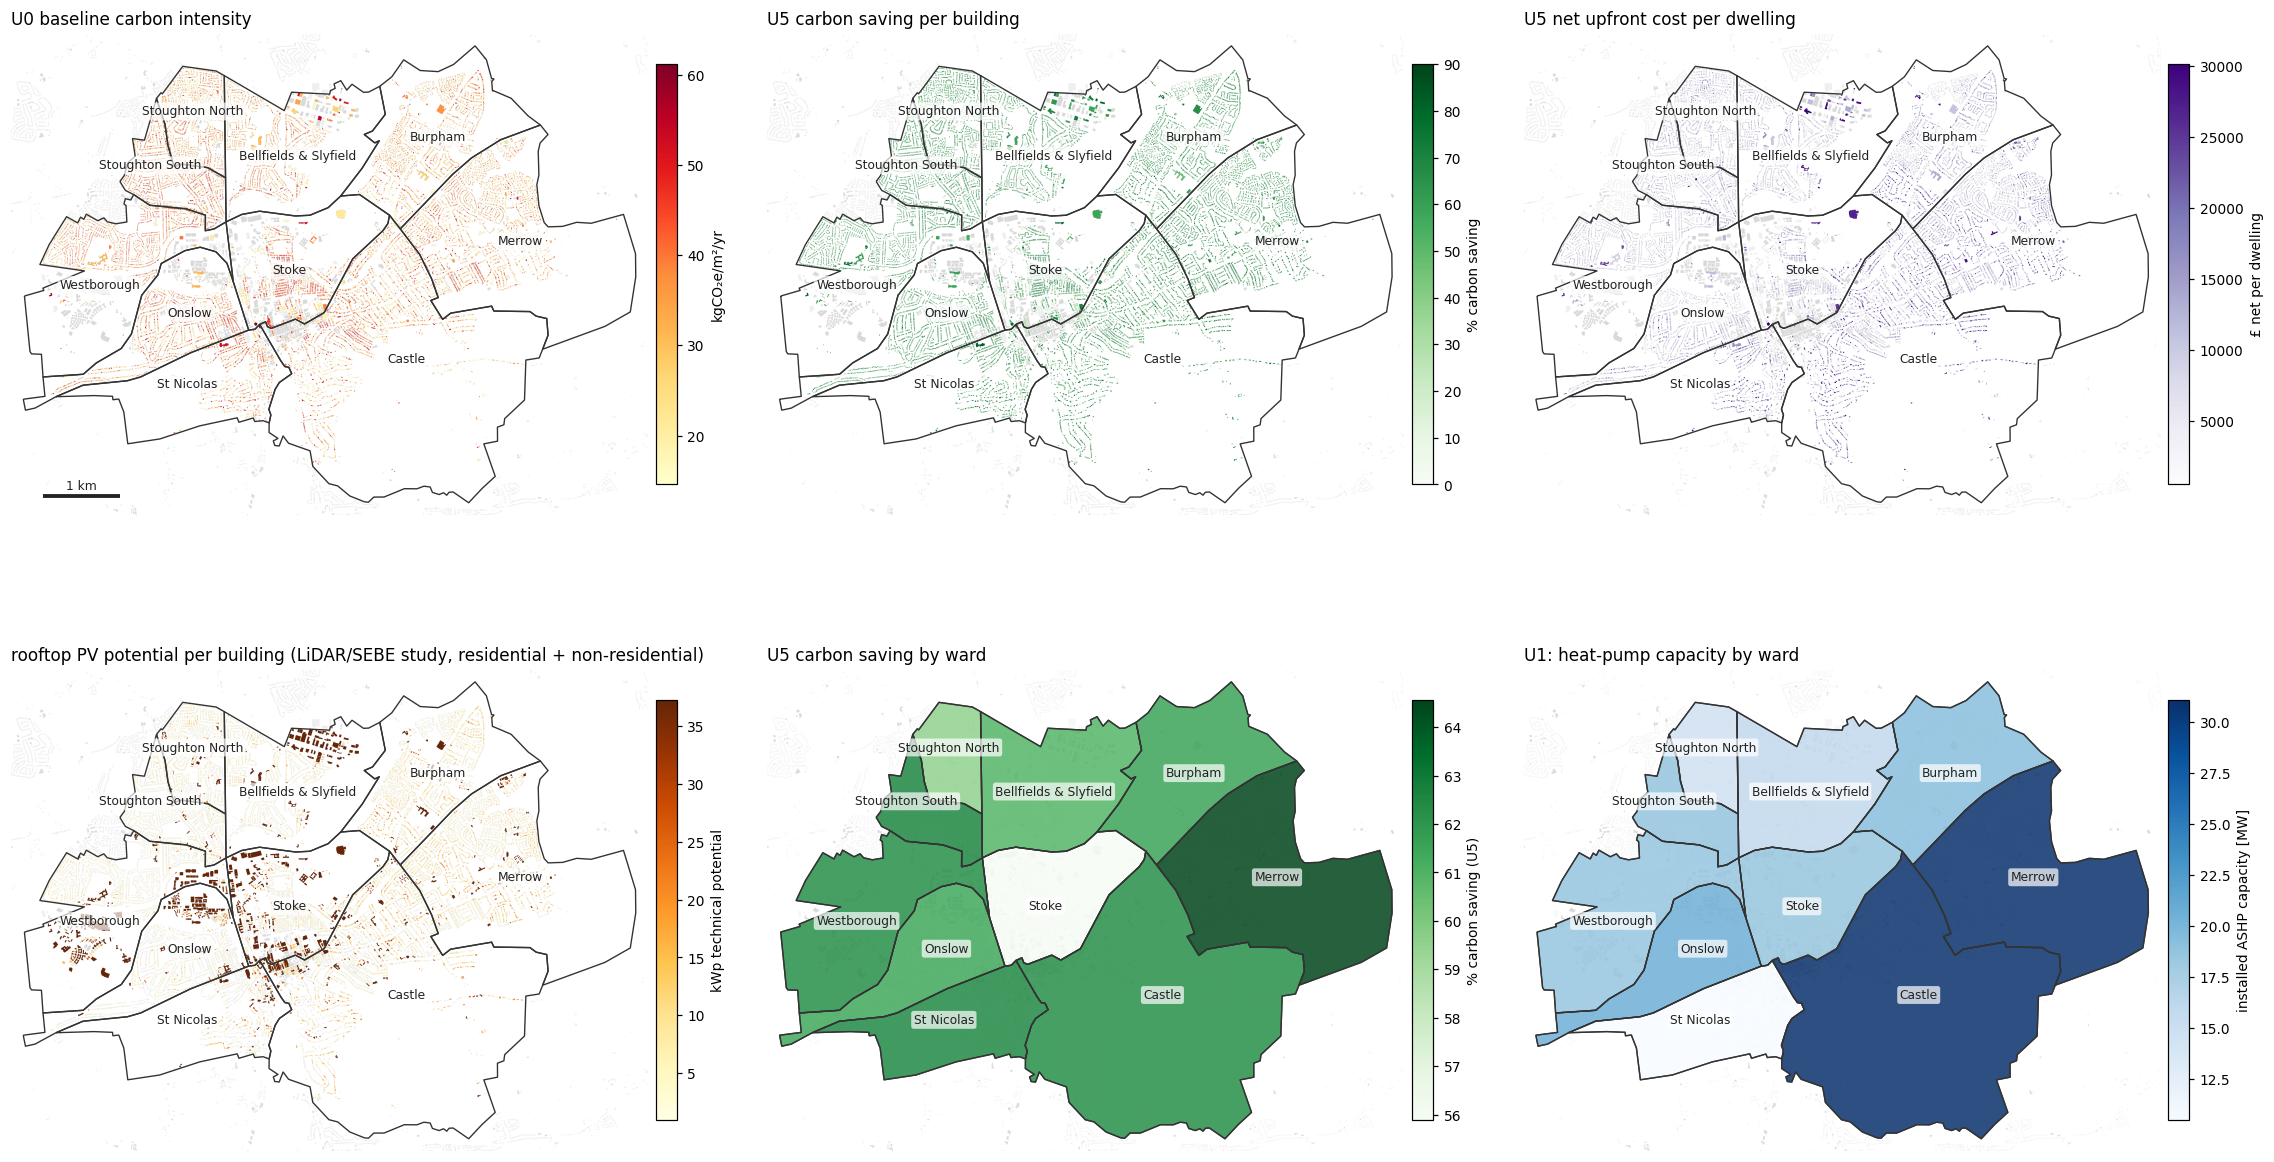

In [7]:
u0, u5, u3 = scen["U0_baseline"].loc[urban_ids], scen["U5_envelope_elec_pv"].loc[urban_ids], scen["U3_envelope_elec"].loc[urban_ids]
fig, axes = plt.subplots(2, 3, figsize=(21, 13))
maps.base_map(axes[0, 0], L); maps.building_map(axes[0, 0], L, maps.per_building(u0["carbon_kg"] / urban["floor_area_final"], urban), label="kgCO₂e/m²/yr"); maps.finish(axes[0, 0], L, title="U0 baseline carbon intensity")
maps.base_map(axes[0, 1], L); maps.building_map(axes[0, 1], L, maps.per_building(100 * (1 - u5["carbon_kg"] / u0["carbon_kg"].replace(0, np.nan)), urban), cmap="Greens", label="% carbon saving", vmin=0, vmax=90); maps.finish(axes[0, 1], L, title="U5 carbon saving per building", bar=False)
maps.base_map(axes[0, 2], L); maps.building_map(axes[0, 2], L, maps.per_building(u5["capex_gross_GBP"] - u5["incentives_GBP"], urban), cmap="Purples", label="£ net per dwelling"); maps.finish(axes[0, 2], L, title="U5 net upfront cost per dwelling", bar=False)
maps.base_map(axes[1, 0], L)
if L.get("pv") is not None:
    pvb = L["pv"].set_index("toid")["peak_power_kwp"]; maps.building_map(axes[1, 0], L, pvb[pvb > 0], cmap="YlOrBr", label="kWp technical potential", vmax=float(pvb.quantile(0.98)))
maps.finish(axes[1, 0], L, title="rooftop PV potential per building (LiDAR/SEBE study, residential + non-residential)", bar=False)
w5 = by_ward[by_ward["scenario"] == "U5_envelope_elec_pv"].set_index("ward")
maps.base_map(axes[1, 1], L, res_color="#f7f7f7"); maps.ward_map(axes[1, 1], L, w5["carbon_saving_pct"], cmap="Greens", label="% carbon saving (U5)"); maps.finish(axes[1, 1], L, title="U5 carbon saving by ward", bar=False)
w1 = by_ward[by_ward["scenario"] == "U1_electrification"].set_index("ward")
maps.base_map(axes[1, 2], L, res_color="#f7f7f7"); maps.ward_map(axes[1, 2], L, w1["hp_MW"], cmap="Blues", label="installed ASHP capacity [MW]"); maps.finish(axes[1, 2], L, title="U1: heat-pump capacity by ward", bar=False)
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_maps_scenarios.png", bbox_inches="tight"); plt.show()

## 3 · Low-hanging fruit: the benefit/cost ranking

For the full package (U5) every dwelling gets its benefit/cost ratio — kgCO₂e saved per pound
of *net* upfront cost over a 15-year horizon — its simple payback against the 12.5-year
threshold, an A–F group by quantile (A = top 5 %), and the hard-to-decarbonise flag.

In [8]:
b0 = scen["U0_baseline"].loc[urban_ids]; s5 = scen["U5_envelope_elec_pv"].loc[urban_ids]
econ = measures.economics(b0, s5, s5, s5)
econ["group"] = measures.rank_groups(econ); econ["HTD"] = measures.hard_to_decarbonise(urban)
econ = econ.join(urban[["ward", "LSOA", "toid", "construction_sa", "tenure", "accommodation_type", "age_band_resolved"]])
econ.to_csv(UBEM_OUT / "10_low_hanging_fruit_U5.csv")
F = measures.ASSUMPTIONS["finance"]
grp = econ[econ["group"].notna()].groupby("group").agg(dwellings=("group", "size"), median_benefit_cost=("benefit_cost_kg_per_GBP", "median"), median_payback_yr=("payback_years", lambda x: float(np.median(x.replace(np.inf, np.nan).dropna())) if x.replace(np.inf, np.nan).notna().any() else np.nan),
                                                     share_payback_ok_pct=("payback_ok", lambda x: 100 * x.mean()), median_net_upfront_GBP=("net_upfront_GBP", "median"), carbon_saving_t=("carbon_saving_kg", lambda x: x.sum() / 1e3),
                                                     rented_share_pct=("tenure", lambda x: 100 * x.astype(str).str.contains("rented").mean()), HTD_share_pct=("HTD", lambda x: 100 * x.mean()))
grp.round(2).to_csv(UBEM_OUT / "10_low_hanging_fruit_groups.csv")
print(f"dwellings with a positive net upfront cost: {(econ['net_upfront_GBP'] > 0).sum():,}; payback <= {F['acceptable_payback_years']} y: {100*econ['payback_ok'].mean():.1f} %; rented share of the stock: {100*urban['tenure'].astype(str).str.contains('rented').mean():.1f} %")
grp.round(2)

dwellings with a positive net upfront cost: 28,591; payback <= 12.5 y: 10.6 %; rented share of the stock: 35.0 %


,dwellings,median_benefit_cost,median_payback_yr,share_payback_ok_pct,median_net_upfront_GBP,carbon_saving_t,rented_share_pct,HTD_share_pct
group,,,,,,,,
A,1430,21.89,10.86,22.45,842.10,2723.27,31.33,14.83
B,2859,7.23,15.19,25.04,5431.14,10313.26,22.56,16.19
C,7148,3.99,22.38,4.95,8957.33,20624.24,25.98,26.50
D,11436,2.35,28.63,5.15,10075.00,20723.29,32.37,18.97
E,4288,1.07,15.58,24.74,7422.75,3106.69,63.95,8.19
F,1430,0.67,25.26,0.00,2726.55,282.30,43.64,7.76


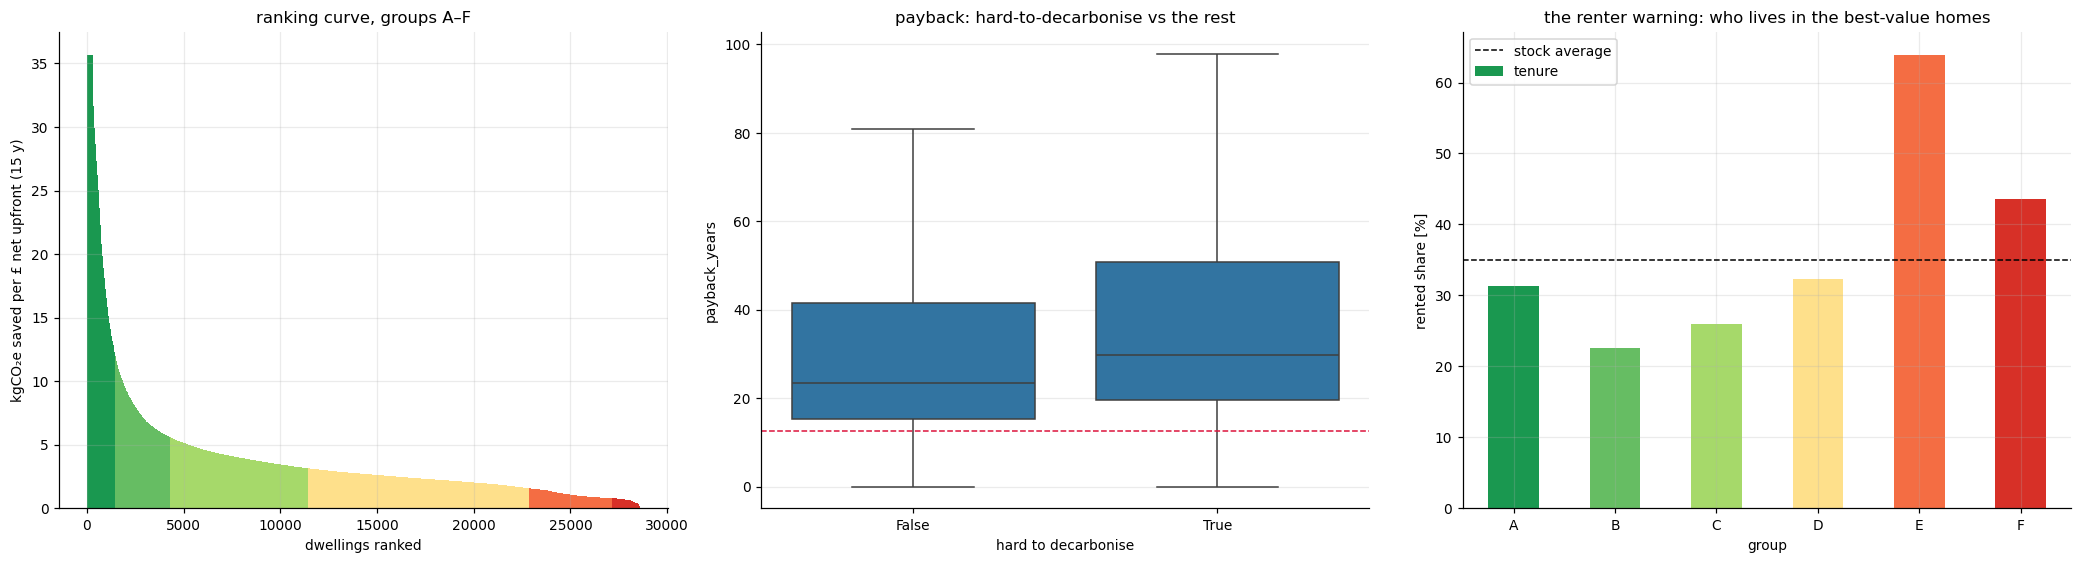

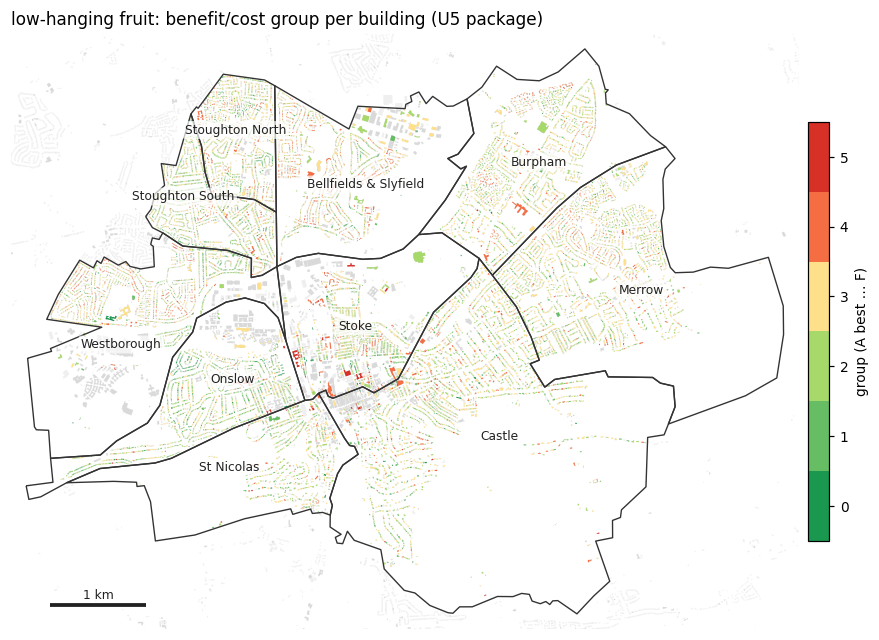

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
r = econ[econ["group"].notna()].sort_values("benefit_cost_kg_per_GBP", ascending=False).reset_index(drop=True)
cols = {"A": "#1a9850", "B": "#66bd63", "C": "#a6d96a", "D": "#fee08b", "E": "#f46d43", "F": "#d73027"}
axes[0].bar(r.index, r["benefit_cost_kg_per_GBP"].clip(upper=r["benefit_cost_kg_per_GBP"].quantile(0.99)), width=1.0, color=r["group"].map(cols)); axes[0].set_xlabel("dwellings ranked"); axes[0].set_ylabel("kgCO₂e saved per £ net upfront (15 y)"); axes[0].set_title("ranking curve, groups A–F")
sns.boxplot(data=econ.replace(np.inf, np.nan), x="HTD", y="payback_years", showfliers=False, ax=axes[1]); axes[1].axhline(F["acceptable_payback_years"], color="crimson", ls="--", lw=1); axes[1].set_title("payback: hard-to-decarbonise vs the rest"); axes[1].set_xlabel("hard to decarbonise")
(econ.groupby("group")["tenure"].apply(lambda x: 100 * x.astype(str).str.contains("rented").mean())).plot.bar(ax=axes[2], color=[cols[g] for g in "ABCDEF"], rot=0)
axes[2].axhline(100 * urban["tenure"].astype(str).str.contains("rented").mean(), color="k", ls="--", lw=1, label="stock average"); axes[2].set_ylabel("rented share [%]"); axes[2].set_title("the renter warning: who lives in the best-value homes"); axes[2].legend()
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_low_hanging_fruit.png", bbox_inches="tight"); plt.show()
fig, ax = plt.subplots(figsize=(11, 9)); maps.base_map(ax, L)
gnum = econ["group"].map({g: i for i, g in enumerate("ABCDEF")}).dropna()
from matplotlib.colors import ListedColormap
maps.building_map(ax, L, maps.per_building(gnum, urban).round(), cmap=ListedColormap([cols[g] for g in "ABCDEF"]), vmin=-0.5, vmax=5.5, label="group (A best … F)"); maps.finish(ax, L, title="low-hanging fruit: benefit/cost group per building (U5 package)")
fig.savefig(FIG_UBEM / "10_map_low_hanging_fruit.png", bbox_inches="tight"); plt.show()

## 4 · Grid decarbonisation view

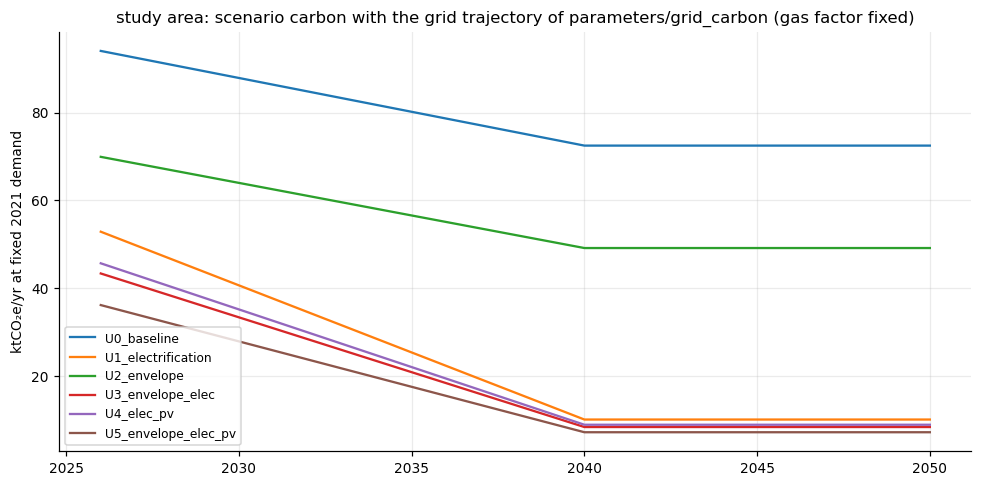

,U0_baseline,U1_electrification,U2_envelope,U3_envelope_elec,U4_elec_pv,U5_envelope_elec_pv
2026,94.0,52.9,69.9,43.4,45.7,36.2
2030,87.9,40.7,64.0,33.4,35.2,27.9
2040,72.5,10.2,49.2,8.5,9.0,7.3
2050,72.5,10.2,49.2,8.5,9.0,7.3


In [10]:
G = measures.ASSUMPTIONS["grid_trajectory"]; years = np.arange(2026, 2051); f_elec = np.interp(years, G["years"], G["elec_kg_per_kWh"])
traj = pd.DataFrame(index=years)
for name, s in scen.items():
    u = s.loc[urban_ids]; gas = u["delivered_gas_kWh"].sum() * measures.ASSUMPTIONS["carbon_kg_per_kWh"]["gas"]
    other = (u["delivered_other_kWh"] * u["systems_fam"].map(measures.ASSUMPTIONS["carbon_kg_per_kWh"]).fillna(measures.ASSUMPTIONS["carbon_kg_per_kWh"]["other"])).sum()
    traj[name] = (gas + other + u["elec_net_kWh"].sum() * f_elec) / 1e6
traj.to_csv(UBEM_OUT / "10_carbon_trajectory_kt.csv")
fig, ax = plt.subplots(figsize=(9, 4.5)); traj.plot(ax=ax); ax.set_ylabel("ktCO₂e/yr at fixed 2021 demand"); ax.set_title("study area: scenario carbon with the grid trajectory of parameters/grid_carbon (gas factor fixed)"); ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_carbon_trajectory.png", bbox_inches="tight"); plt.show()
(traj.loc[[2026, 2030, 2040, 2050]]).round(1)

## 5 · Heat-pump peaks by ward: heat-pump households do not heat like gas-boiler households

Hourly heat output of the representatives (stratified CHAP household draws) under the baseline fabric
(notebook 09) and under the fabric package (simulated here), scaled to every dwelling of each ward by its
floor area. For dwellings on a heat pump the day's heat is re-shaped within the day with the GB field-trial
profiles of heat-pump homes per outdoor-temperature band (Watson, Lomas & Buswell 2021 — 64 % of trial
households heated continuously, against 20 % of gas-boiler households) and carries the trial's annual
uplift; electricity = non-heating load (BREDEM annual × the EFUS winter shape) + heat-pump electricity at the
hourly COP of Ruhnau et al. (2019) with radiators at 40 − T_out (Halloran 2024, eqs 3.4–3.7) + direct electric
heating. The method comparison below shows what the two choices do to the electrified peak: the gas-era
CHAP shape with the earlier Carnot-fraction COP, the gas-era shape with the Ruhnau COP, and the heat-pump
shape with the Ruhnau COP (the tool's setting).

In [11]:
from joblib import Parallel, delayed
idx = pd.date_range("2021-01-01", periods=8760, freq="h"); wx = profiles.epw_hourly(EPW); t_out = wx["T_out_C"].to_numpy()
key = reps.set_index("dwelling_id")[["construction_sa", "size_class"]]
def rep_hourly(file, inp_rep, A, n_real=3):
    if Path(file).exists():
        z = np.load(file, allow_pickle=True); return z["Q_W"], pd.DataFrame(z["meta"], columns=["dwelling_id", "realisation", "construction_sa", "size_class", "heating_pattern", "A_floor"])
    rows_rep = inp_rep.loc[reps["dwelling_id"].to_numpy()]
    tasks = [(rows_rep.iloc[i:i + 1], SEED, k) for k in range(n_real) for i in range(len(rows_rep))]     # stratified draws, as the calibration
    res = Parallel(n_jobs=N_JOBS, batch_size=1)(delayed(simulate_rows)(c, str(EPW), str(PBE_SRC), A, True, s, 2021, post, True, 60, k, n_real) for c, s, k in tasks)
    Q, meta = [], []
    for (c, s, k), r in zip(tasks, res):
        r = r[0]
        if "hourly_Q_HC_W" in r:
            Q.append(np.clip(np.asarray(r["hourly_Q_HC_W"], np.float32), 0, None)); did = int(r["dwelling_id"]); meta.append([did, k, key.loc[did, "construction_sa"], key.loc[did, "size_class"], r.get("heating_pattern"), r["A_floor"]])
    Q = np.stack(Q); meta = pd.DataFrame(meta, columns=["dwelling_id", "realisation", "construction_sa", "size_class", "heating_pattern", "A_floor"]); np.savez(file, Q_W=Q, meta=meta.to_numpy(dtype=object)); return Q, meta
t0 = time.time()
Q0, meta0 = rep_hourly(UBEM_OUT / "09_representative_hourly.npz", inputs, A_cal, n_real=3)
A_fab = UKGeometryAssumptions().with_(wall_u_scale=phys_fab["wall_u_scale"], roof_u_scale=phys_fab["roof_u_scale"], window_u_scale=phys_fab["window_u_scale"], infil_scale=phys_fab["infil_scale"], gains_scale=phys_fab["gains_scale"], setpoint_offset_c=phys_fab["setpoint_offset_c"], stochastic_setback_c=phys_fab.get("setback_c", 12.0))
Qf, metaf = rep_hourly(UBEM_OUT / "10_representative_hourly_fabric.npz", inp_fab, A_fab, n_real=3)
print(f"hourly representatives ready in {(time.time()-t0)/60:.1f} min: baseline {Q0.shape}, fabric {Qf.shape}")
def group_profiles(Q, meta):
    meta = meta.copy(); meta["A_floor"] = meta["A_floor"].astype(float)
    Qm2 = Q / meta["A_floor"].to_numpy()[:, None]
    return {g: Qm2[ii].mean(axis=0) for g, ii in meta.groupby(["construction_sa", "size_class"]).indices.items()}
prof0, proff = group_profiles(Q0, meta0), group_profiles(Qf, metaf)
prof0_hp, proff_hp = HP.heat_pump_group_profiles(prof0, t_out), HP.heat_pump_group_profiles(proff, t_out)     # heat-pump households: trial shape per temperature band + annual uplift
BASE_ELEC_SHAPE = np.array(PRM.load("demand_model", "non_heating_electricity_shape")["hourly_weights"], float); BASE_ELEC_SHAPE /= BASE_ELEC_SHAPE.mean()
base_shape = BASE_ELEC_SHAPE[idx.hour]

hourly representatives ready in 0.0 min: baseline (306, 8760), fabric (306, 8760)


In [12]:
HP_FAM = "S.HeatPump"; BOILER_FAMS = ["S.GasBoiler", "S.GasCommunal", "S.OilBoiler", "S.LPGBoiler", "S.SolidFuel"]; DIRECT = ["S.ElecResistive", "S.ElecStorage"]
def ward_profiles(scn_name, prof, prof_hp, ward, cop="ruhnau"):
    """Hourly ward profiles (W): heat by system class, gas, electricity. Heat-pump dwellings take `prof_hp`; cop 'ruhnau' or 'carnot'."""
    s = scen[scn_name].loc[urban_ids]; s = s[s["ward"] == ward]
    fam = s["systems_fam"].astype(str); A = s["floor_area_final"]; g = list(zip(s["construction_sa"], s["size_class"] if "size_class" in s else inputs.loc[s.index, "size_class"]))
    heat = {"hp": np.zeros(8760), "boiler": np.zeros(8760), "direct": np.zeros(8760)}
    area = pd.DataFrame({"g": g, "A": A.to_numpy(), "cls": np.where(fam.eq(HP_FAM), "hp", np.where(fam.isin(DIRECT), "direct", "boiler"))}).groupby(["cls", "g"])["A"].sum()
    for (cls, gg), a in area.items():
        src = prof_hp if cls == "hp" else prof
        if gg in src: heat[cls] += src[gg] * a
    base = s["appliances_kWh"].sum() * 1000 / 8760 * base_shape                          # W, BREDEM non-heating electricity with the EFUS winter shape
    hp_el = HP.hp_electric_w(heat["hp"], t_out) if cop == "ruhnau" else profiles.hp_electric_w(heat["hp"], t_out, 45.0)
    elec = base + hp_el + heat["direct"]
    return {"heat_W": heat["hp"] + heat["boiler"] + heat["direct"], "hp_heat_W": heat["hp"], "gas_W": heat["boiler"] / post["boiler_eff"], "elec_W": elec, "hp_elec_W": hp_el, "base_W": base, "n": len(s)}
WARDS = sorted(urban["ward"].dropna().unique())
rows, tot = [], {}
for scn_name, prof, prof_hp in [("U0_baseline", prof0, prof0_hp), ("U1_electrification", prof0, prof0_hp), ("U3_envelope_elec", proff, proff_hp)]:
    tot[scn_name] = {"elec_W": np.zeros(8760), "gas_W": np.zeros(8760), "heat_W": np.zeros(8760), "hp_heat_W": np.zeros(8760), "hp_elec_W": np.zeros(8760)}
    for w in WARDS:
        p = ward_profiles(scn_name, prof, prof_hp, w)
        for k in tot[scn_name]: tot[scn_name][k] += p[k]
        se, sg = profiles.peak_stats(p["elec_W"] / 1000, idx), profiles.peak_stats(p["gas_W"] / 1000, idx)
        rows.append({"ward": w, "scenario": scn_name, "dwellings": p["n"], "elec_peak_MW": se["peak_kW"] / 1000, "elec_peak_hour": se["peak_hour"], "elec_top50_hour": se["top50_hour_mode"],
                     "elec_p99_MW": se["p99_kW"] / 1000, "elec_mean_MW": se["mean_kW"] / 1000, "gas_peak_MW": sg["peak_kW"] / 1000, "heat_peak_MW": p["heat_W"].max() / 1e6, "hp_elec_at_peak_MW": p["hp_elec_W"][np.argmax(p["elec_W"])] / 1e6})
peaks = pd.DataFrame(rows); peaks.to_csv(UBEM_OUT / "10_ward_peaks.csv", index=False)
piv = peaks.pivot(index="ward", columns="scenario", values="elec_peak_MW"); piv["U1/U0"] = piv["U1_electrification"] / piv["U0_baseline"]; piv["U3/U0"] = piv["U3_envelope_elec"] / piv["U0_baseline"]
hrs = peaks.pivot(index="ward", columns="scenario", values="elec_peak_hour")
sys_peaks = {k: profiles.peak_stats(v["elec_W"] / 1000, idx) for k, v in tot.items()}
pd.DataFrame({k: v["elec_W"] / 1e6 for k, v in tot.items()}, index=idx).rename_axis("hour").to_csv(UBEM_OUT / "10_tenward_hourly_elec_MW.csv")
pd.DataFrame({f"{k}_{q}_MW": v[f"{q}_W"] / 1e6 for k, v in tot.items() for q in ("gas", "heat")}, index=idx).rename_axis("hour").to_csv(UBEM_OUT / "10_tenward_hourly_gas_heat_MW.csv")
print("study-area electricity peak (time-aligned sum, no diversity factor):", {k: f"{v['peak_kW']/1000:.1f} MW at {v['peak_hour']:02d}:00 ({v['peak_time'][:10]})" for k, v in sys_peaks.items()})
u1 = tot["U1_electrification"]; print(f"U1 implied seasonal COP of the hourly model: {HP.seasonal_cop(u1['hp_heat_W'], u1['hp_elec_W']):.2f} (annual accounting keeps the evidence SPF {post['hp_scop']})")
# method comparison for U1: gas-era shape + Carnot COP (earlier approach) | gas-era shape + Ruhnau COP | heat-pump shape + Ruhnau COP (this tool)
variants = {"gas-era shape, Carnot COP": (prof0, "carnot"), "gas-era shape, Ruhnau COP": (prof0, "ruhnau"), "heat-pump shape (Watson), Ruhnau COP": (prof0_hp, "ruhnau")}
cmp_rows, cmp_prof = [], {}
for lab, (ph, cop) in variants.items():
    e = np.zeros(8760); h = np.zeros(8760); he = np.zeros(8760)
    for w in WARDS:
        pw = ward_profiles("U1_electrification", prof0, ph, w, cop=cop); e += pw["elec_W"]; h += pw["hp_heat_W"]; he += pw["hp_elec_W"]
    st_ = profiles.peak_stats(e / 1000, idx); cmp_prof[lab] = e / 1e6
    cmp_rows.append({"variant": lab, "elec_peak_MW": st_["peak_kW"] / 1000, "peak_hour": st_["peak_hour"], "p99_MW": st_["p99_kW"] / 1000, "hp_heat_peak_MW": h.max() / 1e6,
                     "hp_annual_heat_GWh": h.sum() / 1e9, "hp_annual_elec_GWh": he.sum() / 1e9, "implied_SCOP": HP.seasonal_cop(h, he), "max_ramp_MW_per_h": np.abs(np.diff(e)).max() / 1e6})
cmp_tab = pd.DataFrame(cmp_rows).set_index("variant"); cmp_tab.to_csv(UBEM_OUT / "10_peak_method_comparison.csv")
print("U1 electrification, ten-ward electricity peak by method:"); print(cmp_tab.round(2).to_string())
piv.round(1).join(hrs.add_suffix("_hour"))

study-area electricity peak (time-aligned sum, no diversity factor): {'U0_baseline': '29.6 MW at 18:00 (2021-12-14)', 'U1_electrification': '78.0 MW at 08:00 (2021-01-20)', 'U3_envelope_elec': '58.6 MW at 08:00 (2021-01-20)'}
U1 implied seasonal COP of the hourly model: 3.94 (annual accounting keeps the evidence SPF 2.8)


U1 electrification, ten-ward electricity peak by method:
                                      elec_peak_MW  peak_hour  p99_MW  hp_heat_peak_MW  hp_annual_heat_GWh  hp_annual_elec_GWh  implied_SCOP  max_ramp_MW_per_h
variant                                                                                                                                                        
gas-era shape, Carnot COP                   108.76          7   73.84           184.25              260.24               91.40          2.85              41.14
gas-era shape, Ruhnau COP                    91.78          7   60.98           184.25              260.24               66.75          3.90              34.10
heat-pump shape (Watson), Ruhnau COP         77.98          8   57.67           152.23              281.06               71.38          3.94              17.78


scenario,U0_baseline,U1_electrification,U3_envelope_elec,U1/U0,U3/U0,U0_baseline_hour,U1_electrification_hour,U3_envelope_elec_hour
ward,,,,,,,,
Bellfields & Slyfield,2.1,5.7,4.6,2.7,2.2,18,19,18
Burpham,3.7,8.3,6.6,2.2,1.8,18,7,7
Castle,5.5,14.3,10.4,2.6,1.9,18,8,7
Merrow,3.6,11.1,8.6,3.1,2.4,18,8,18
Onslow,2.3,7.2,5.3,3.2,2.3,18,19,19
St Nicolas,1.6,4.4,3.0,2.7,1.9,18,8,18
Stoke,4.6,9.2,6.7,2.0,1.4,7,7,7
Stoughton North,2.1,5.3,4.4,2.5,2.0,18,8,18
Stoughton South,2.2,6.5,4.8,3.0,2.2,18,19,19


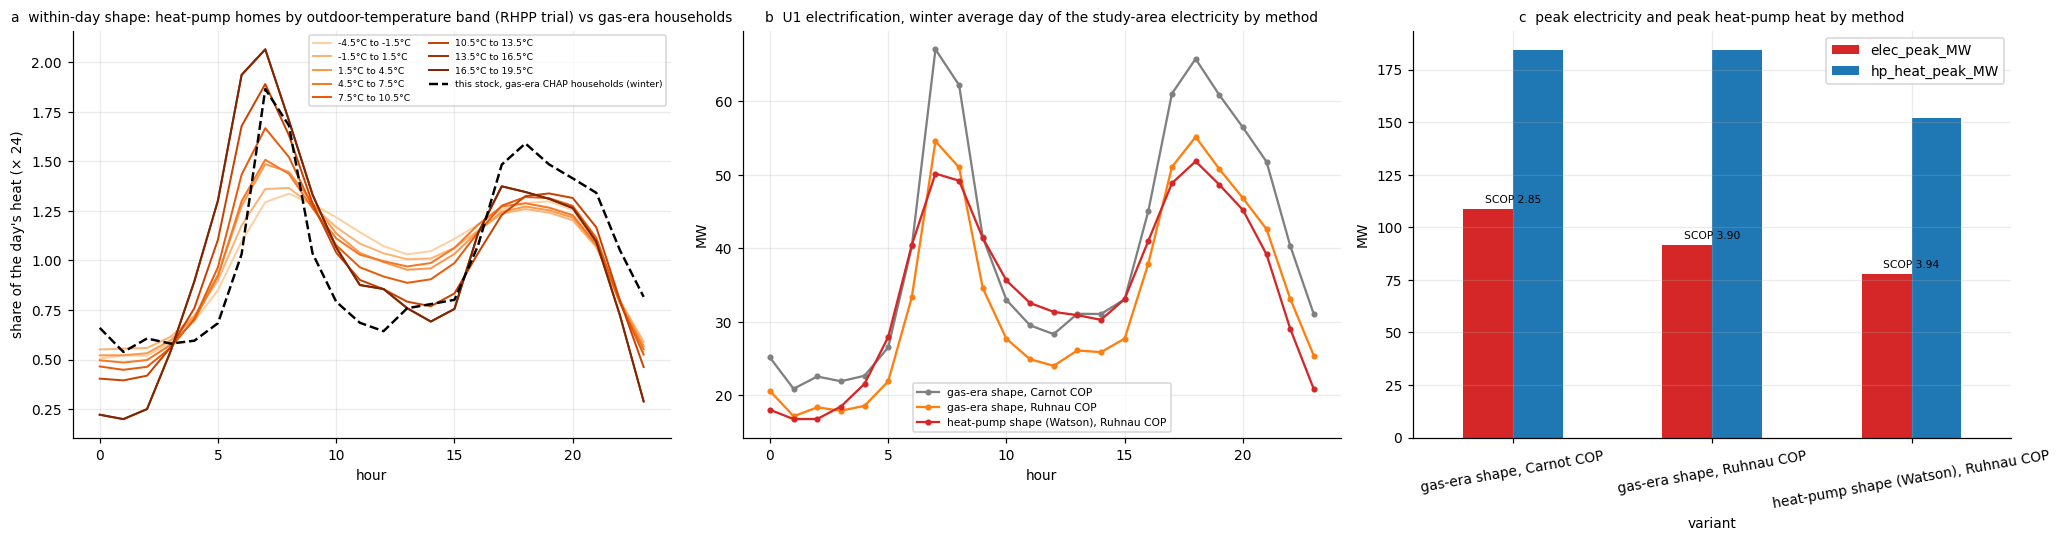

In [13]:
# the heat-pump behaviour figure: trial shapes vs the gas-era CHAP shape, and what they do to the electrified peak
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
shapes = HP.hourly_shape("ASHP"); cmap = plt.get_cmap("Oranges")
for b, lab in enumerate(HP.BAND_LABELS):
    axes[0].plot(range(24), shapes[b] * 24, color=cmap(0.25 + 0.75 * b / (len(HP.BAND_LABELS) - 1)), lw=1.3, label=lab)
gas_day = profiles.average_day(tot["U0_baseline"]["heat_W"] / 1e6, idx); axes[0].plot(range(24), gas_day / gas_day.mean(), color="k", ls="--", lw=1.6, label="this stock, gas-era CHAP households (winter)")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("share of the day's heat (× 24)"); axes[0].set_title("a  within-day shape: heat-pump homes by outdoor-temperature band (RHPP trial) vs gas-era households", fontsize=9); axes[0].legend(fontsize=6, ncol=2)
for lab, c in zip(variants, ["grey", "tab:orange", "tab:red"]):
    axes[1].plot(range(24), profiles.average_day(cmp_prof[lab], idx), color=c, marker="o", ms=3, label=lab)
axes[1].set_xlabel("hour"); axes[1].set_ylabel("MW"); axes[1].set_title("b  U1 electrification, winter average day of the study-area electricity by method", fontsize=9); axes[1].legend(fontsize=7)
cmp_tab[["elec_peak_MW", "hp_heat_peak_MW"]].plot.bar(ax=axes[2], rot=10, color=["tab:red", "tab:blue"]); axes[2].set_ylabel("MW"); axes[2].set_title("c  peak electricity and peak heat-pump heat by method", fontsize=9)
for k, v in enumerate(cmp_tab["implied_SCOP"]): axes[2].annotate(f"SCOP {v:.2f}", (k, cmp_tab["elec_peak_MW"].iloc[k]), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=7)
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_heat_pump_shape.png", bbox_inches="tight"); plt.show()

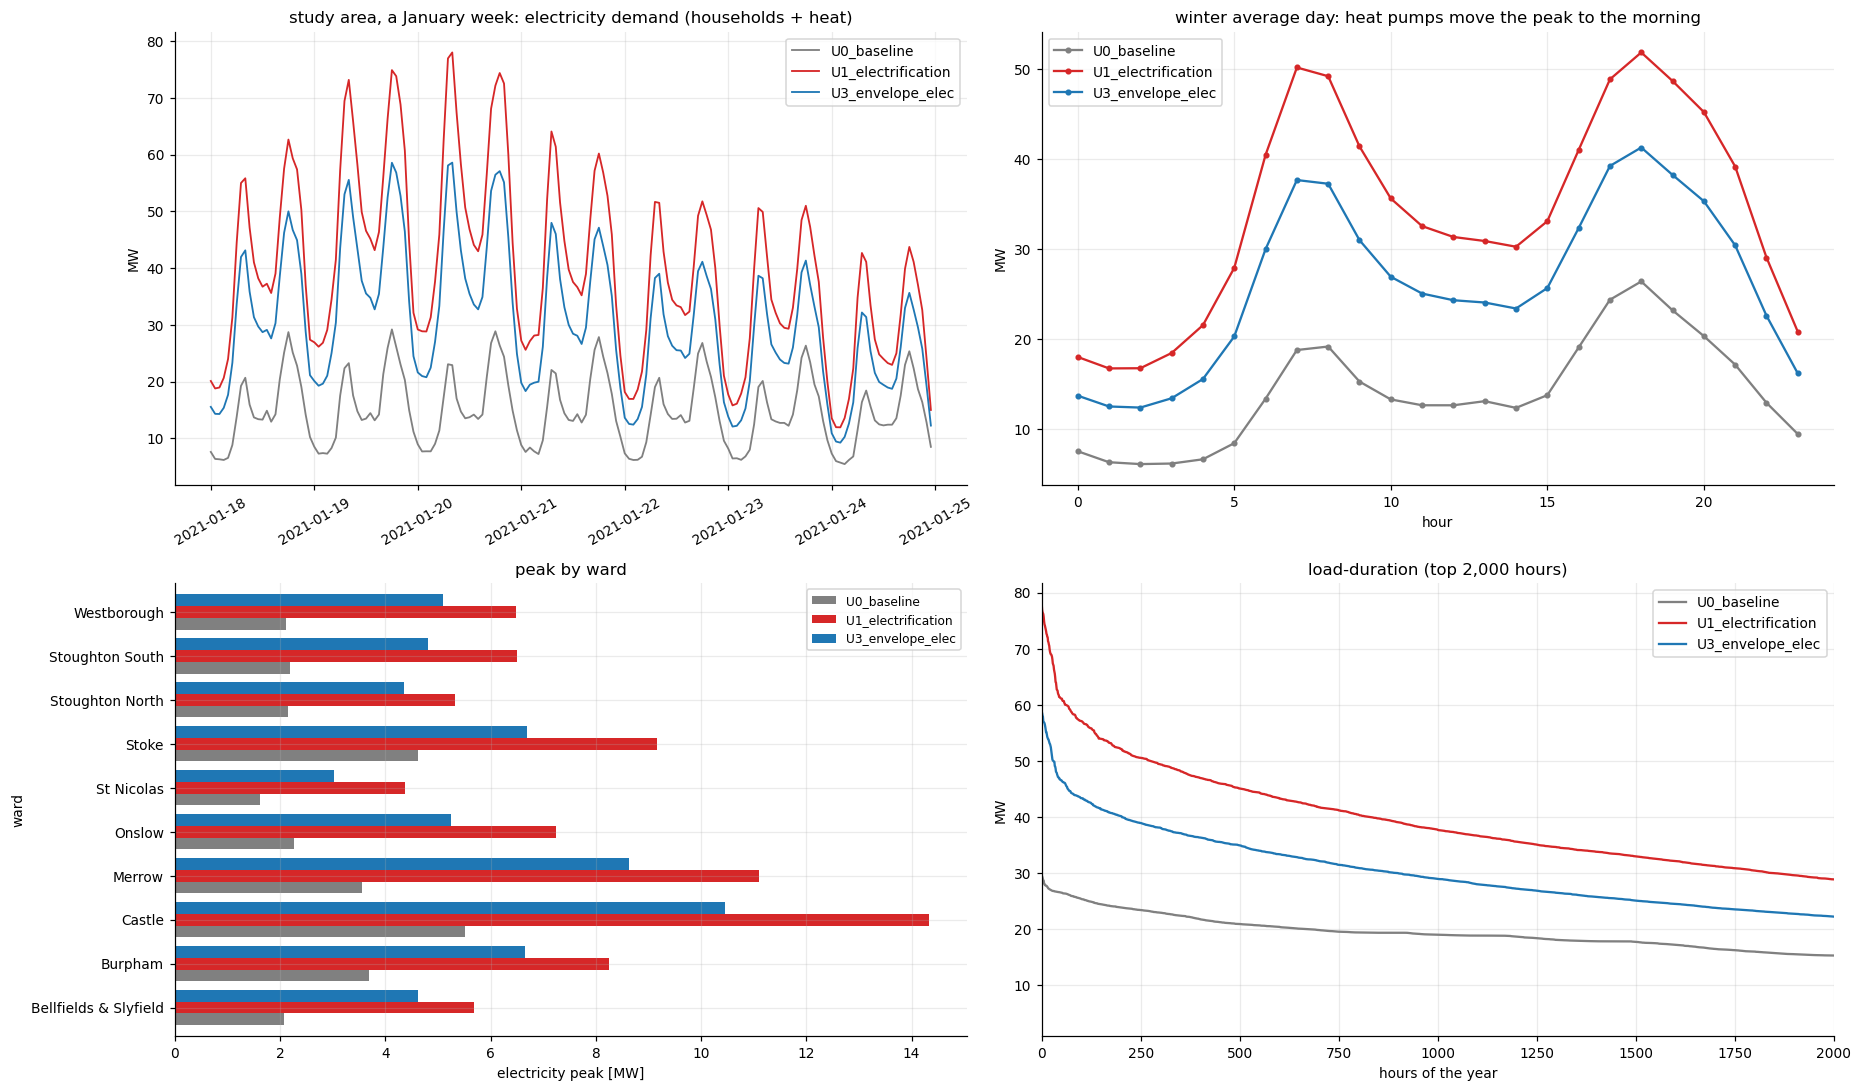

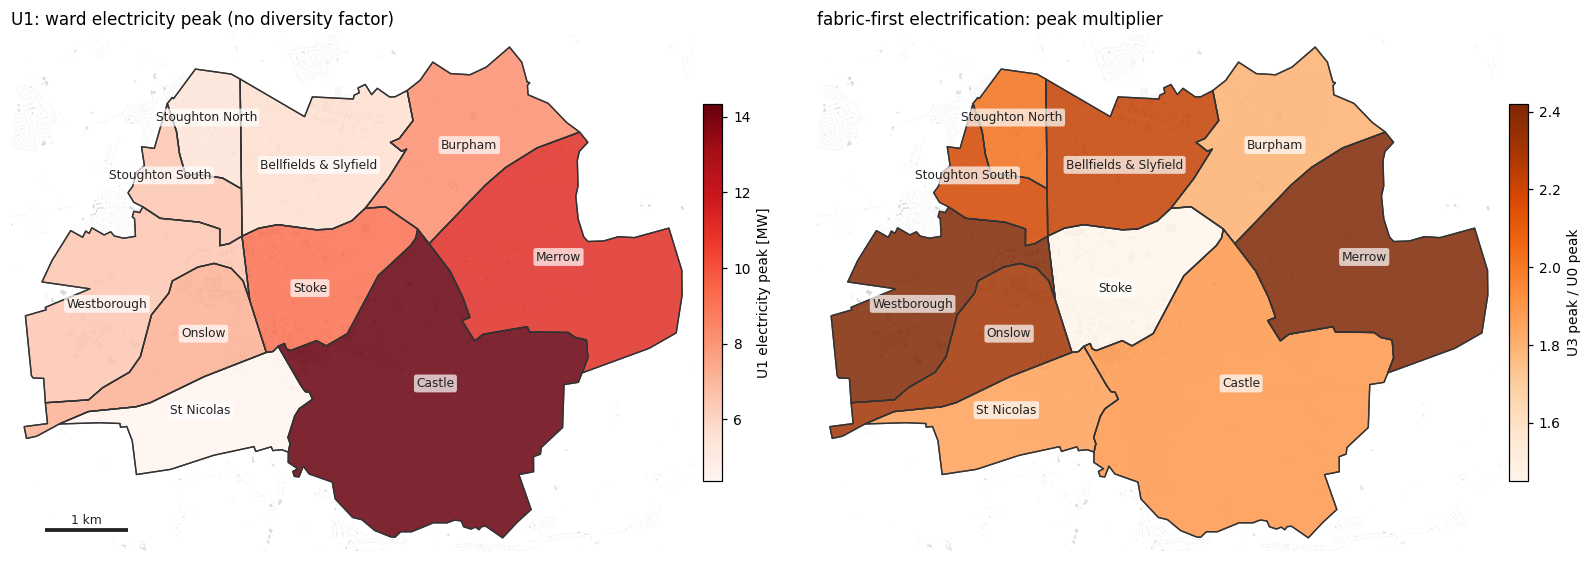

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
w = slice(idx.get_loc("2021-01-18 00:00"), idx.get_loc("2021-01-25 00:00"))
for k, c in zip(tot, ["grey", "tab:red", "tab:blue"]):
    axes[0, 0].plot(idx[w], tot[k]["elec_W"][w] / 1e6, color=c, lw=1.2, label=k)
axes[0, 0].set_ylabel("MW"); axes[0, 0].set_title("study area, a January week: electricity demand (households + heat)"); axes[0, 0].legend(); axes[0, 0].tick_params(axis="x", rotation=30)
for k, c in zip(tot, ["grey", "tab:red", "tab:blue"]):
    axes[0, 1].plot(range(24), profiles.average_day(tot[k]["elec_W"] / 1e6, idx), color=c, label=k, marker="o", ms=3)
axes[0, 1].set_xlabel("hour"); axes[0, 1].set_ylabel("MW"); axes[0, 1].set_title("winter average day: heat pumps move the peak to the morning"); axes[0, 1].legend()
piv[["U0_baseline", "U1_electrification", "U3_envelope_elec"]].plot.barh(ax=axes[1, 0], width=0.8, color=["grey", "tab:red", "tab:blue"]); axes[1, 0].set_xlabel("electricity peak [MW]"); axes[1, 0].set_title("peak by ward"); axes[1, 0].legend(fontsize=8)
for k, c in zip(tot, ["grey", "tab:red", "tab:blue"]):
    axes[1, 1].plot(np.arange(8760), profiles.load_duration(tot[k]["elec_W"] / 1e6), color=c, label=k)
axes[1, 1].set_xlim(0, 2000); axes[1, 1].set_xlabel("hours of the year"); axes[1, 1].set_ylabel("MW"); axes[1, 1].set_title("load-duration (top 2,000 hours)"); axes[1, 1].legend()
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_peaks.png", bbox_inches="tight"); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
maps.base_map(axes[0], L, res_color="#f7f7f7"); maps.ward_map(axes[0], L, piv["U1_electrification"], cmap="Reds", label="U1 electricity peak [MW]"); maps.finish(axes[0], L, title="U1: ward electricity peak (no diversity factor)")
maps.base_map(axes[1], L, res_color="#f7f7f7"); maps.ward_map(axes[1], L, piv["U3/U0"], cmap="Oranges", label="U3 peak / U0 peak"); maps.finish(axes[1], L, title="fabric-first electrification: peak multiplier", bar=False)
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_peaks_map.png", bbox_inches="tight"); plt.show()

## 6 · Secondary-substation cells (nearest-substation assignment, screening only)

Every building is assigned to its nearest secondary substation (Voronoi-style cells,
`data/inputs/network/`). Each cell's dwellings are summed time-aligned under U0 / U1 / U3 and the cell peak is
compared with the transformer's ONAN rating — a screening view, not a network study (the assignment is a
spatial inference, never a verified connection; coverage is partial).

dwellings assigned to a substation cell: 100 % (271 cells)


cells above 100 % of ONAN x 0.95 at the modelled peak: U0 2, U1 68, U3 27 of 271 (partial coverage, screening only)


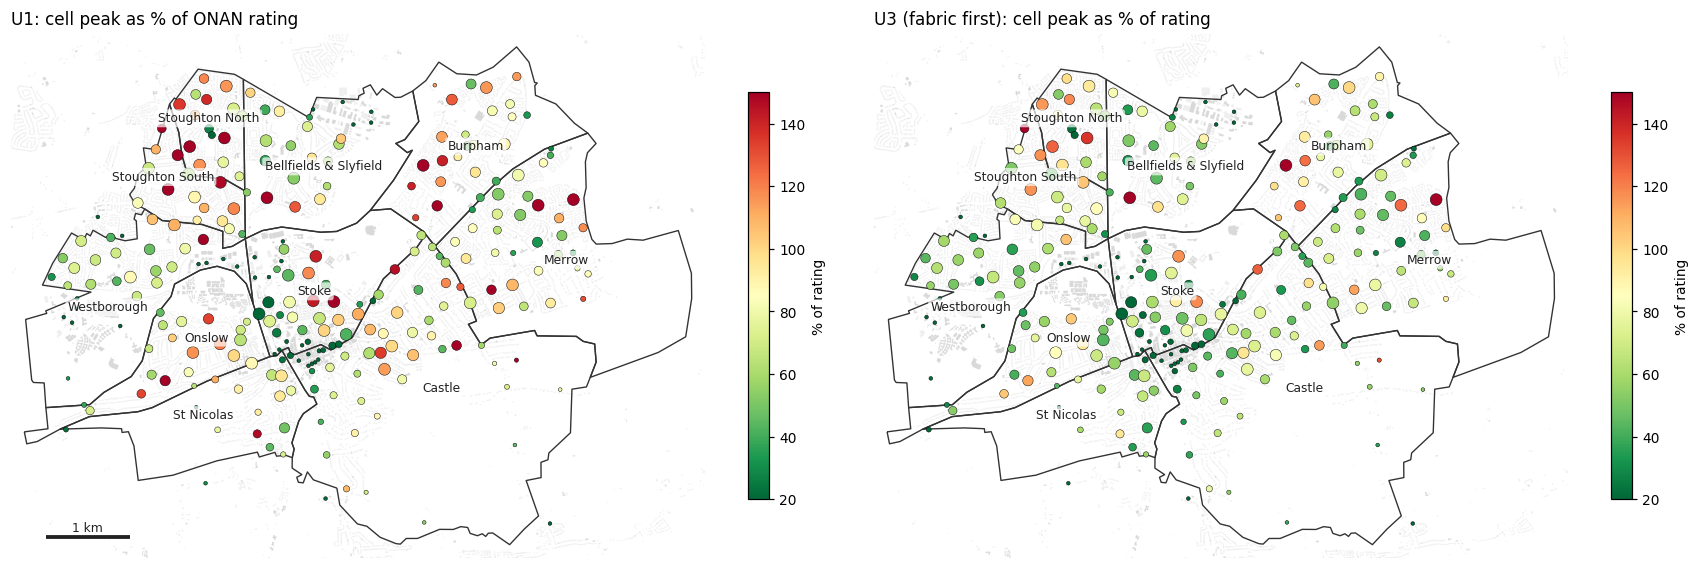

In [15]:
qb_file = NETWORK_BUILDINGS_CSV; sub_file = SUBSTATIONS_CSV
if qb_file.exists() and sub_file.exists():
    qb = pd.read_csv(qb_file, usecols=["egid", "id_transformer", "x", "y"]); qb["UPRN"] = qb["egid"].astype("Int64").astype(str)
    subs = pd.read_csv(sub_file)[["functionallocation", "onanrating", "customer_count", "easting", "northing"]].drop_duplicates("functionallocation").set_index("functionallocation")
    u = urban[["UPRN", "ward", "floor_area_final", "systems_fam", "construction_sa", "size_class"]].copy(); u["UPRN"] = u["UPRN"].astype("Int64").astype(str)
    u = u.merge(qb[["UPRN", "id_transformer"]], on="UPRN", how="left"); u.index = urban.index
    cov = u["id_transformer"].notna().mean(); print(f"dwellings assigned to a substation cell: {100*cov:.0f} % ({u['id_transformer'].nunique()} cells)")
    rows = []
    for cell, g in u.dropna(subset=["id_transformer"]).groupby("id_transformer"):
        out = {"cell": cell, "dwellings": len(g), "ward": g["ward"].mode().iloc[0]}
        for scn_name, prof, prof_hp in [("U0_baseline", prof0, prof0_hp), ("U1_electrification", prof0, prof0_hp), ("U3_envelope_elec", proff, proff_hp)]:
            s = scen[scn_name].loc[g.index]; fam = s["systems_fam"].astype(str)
            hp = np.zeros(8760); direct = np.zeros(8760)
            for (gg, a, f) in zip(zip(g["construction_sa"], g["size_class"]), g["floor_area_final"], fam):
                if f == "S.HeatPump" and gg in prof_hp: hp += prof_hp[gg] * a
                elif f in DIRECT and gg in prof: direct += prof[gg] * a
            elec = s["appliances_kWh"].sum() * 1000 / 8760 * base_shape + HP.hp_electric_w(hp, t_out) + direct
            out[f"{scn_name}_peak_kW"] = elec.max() / 1000
        rows.append(out)
    cells = pd.DataFrame(rows).set_index("cell").join(subs)
    cells["rating_kW"] = cells["onanrating"] * 0.95
    for k in ("U1_electrification", "U3_envelope_elec"):
        cells[f"inc_{k[:2]}_kW"] = cells[f"{k}_peak_kW"] - cells["U0_baseline_peak_kW"]; cells[f"{k[:2]}_util_pct"] = 100 * cells[f"{k}_peak_kW"] / cells["rating_kW"]
    cells.to_csv(UBEM_OUT / "10_substation_cells.csv")
    print(f"cells above 100 % of ONAN x 0.95 at the modelled peak: U0 {(cells['U0_baseline_peak_kW'] > cells['rating_kW']).sum()}, U1 {(cells['U1_util_pct'] > 100).sum()}, U3 {(cells['U3_util_pct'] > 100).sum()} of {len(cells)} (partial coverage, screening only)")
    import geopandas as gpd
    pts = gpd.GeoDataFrame(cells, geometry=gpd.points_from_xy(cells["easting"], cells["northing"], crs=27700))
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, col, ttl in zip(axes, ["U1_util_pct", "U3_util_pct"], ["U1: cell peak as % of ONAN rating", "U3 (fabric first): cell peak as % of rating"]):
        maps.base_map(ax, L); pts.plot(ax=ax, column=col, cmap="RdYlGn_r", vmin=20, vmax=150, markersize=np.clip(pts["dwellings"] / 3, 6, 60), legend=True, legend_kwds={"label": "% of rating", "shrink": 0.55}, zorder=8, edgecolor="k", linewidth=0.3)
        maps.finish(ax, L, title=ttl, bar=(col == "U1_util_pct"))
    plt.tight_layout(); fig.savefig(FIG_UBEM / "10_substation_cells.png", bbox_inches="tight"); plt.show()
    cells.sort_values("U1_util_pct", ascending=False).head(10).round(1)
else:
    print("substation files not found in data/inputs/network - section skipped")

## 7 · Building-fabric heating flexibility (Halloran 2024)

How long can a home go without heat before it falls below comfort, and how much heat can its fabric store?
Halloran (2024, chapters 5–6) answers this per region with a thermal capacity C (SAP medium thermal mass ×
floor area), a heat-loss rate H (kW/K) and their ratio, the thermal time constant τ = C/H; Newton cooling from
21 °C to the WHO minimum of 18 °C gives the *comfortable heat-free hours* at an outdoor temperature, and a
3 K flexibility window gives the thermal energy storage C·ΔT that a PyPSA model can dispatch with a heat pump
of 10 kW per household and hourly standing loss 1 − e^(−1/τ). EnerMap has the geometry of every dwelling, so
all of this is evaluated per dwelling (baseline fabric and after the fabric package) and aggregated per ward
here and per cluster in the PyPSA-LAEP interface (notebook 11). For comparison, her GB regional medians are a
time constant of 30.6 h and 6.4 comfortable heat-free hours at a uniform 5 °C.

In [16]:
fx_in = urban[["floor_area_final", "ward", "construction_sa", "accommodation_type", "toid"]].copy()
fx_in["HTC_W_K"] = htc0.reindex(fx_in.index); fx_in["HTC_W_K_fab"] = htc_fab.reindex(fx_in.index)
wt = FX.winter_temperature_percentiles(t_out, idx)
flex0 = FX.dwelling_flexibility(fx_in, htc_col="HTC_W_K", winter_temps=wt)
flexf = FX.dwelling_flexibility(fx_in, htc_col="HTC_W_K_fab", winter_temps=wt).add_suffix("_fabric")
flex = fx_in.join(flex0).join(flexf); flex["ashp_kW_U1"] = scen["U1_electrification"].loc[urban_ids, "ashp_kW"]
flex.to_parquet(UBEM_OUT / "10_flexibility_dwellings.parquet")
by_ward = FX.aggregate(flex0.join(fx_in[["ward"]]), "ward", hp_capacity_kW=flex["ashp_kW_U1"]).join(FX.aggregate(flexf.join(fx_in[["ward"]]).rename(columns=lambda c: c.replace("_fabric", "")), "ward")[["time_constant_h_mean", "tes_energy_kWh"]].add_suffix("_fabric"))
by_ward.round(2).to_csv(UBEM_OUT / "10_flexibility_by_ward.csv")
ref_t = FX._F["reference_outdoor_C"]
print(f"winter daily-mean temperature percentiles of the weather year: {wt}")
print(f"time constant: median {flex0['time_constant_h'].median():.1f} h (p10-p90 {flex0['time_constant_h'].quantile(0.1):.1f}-{flex0['time_constant_h'].quantile(0.9):.1f}); after the fabric package {flexf['time_constant_h_fabric'].median():.1f} h")
print(f"comfortable heat-free hours (21 -> 18 C) at {ref_t:g} C: median {flex0[f'heat_free_hours_at_{ref_t:g}C'].median():.1f} h, at the 5th-percentile winter day {flex0['heat_free_hours_p5'].median():.1f} h; fabric package at {ref_t:g} C: {flexf[f'heat_free_hours_at_{ref_t:g}C_fabric'].median():.1f} h")
print(f"thermal energy storage in the fabric (3 K window): {flex0['tes_energy_kWh'].sum()/1e3:.0f} MWh_th over {len(flex0):,} dwellings; Halloran's heat-pump capacity rule 10 kW/dwelling = {10*len(flex0)/1e3:.0f} MW, sized ASHPs of U1 {flex['ashp_kW_U1'].sum()/1e3:.0f} MW")
by_ward.round(2)

winter daily-mean temperature percentiles of the weather year: {'p5': -0.9189583333333331, 'p40': 4.679166666666667, 'lowest': -3.0666666666666664}
time constant: median 24.7 h (p10-p90 15.5-45.7); after the fabric package 28.6 h
comfortable heat-free hours (21 -> 18 C) at 5 C: median 5.1 h, at the 5th-percentile winter day 3.6 h; fabric package at 5 C: 5.9 h
thermal energy storage in the fabric (3 K window): 629 MWh_th over 28,663 dwellings; Halloran's heat-pump capacity rule 10 kW/dwelling = 287 MW, sized ASHPs of U1 199 MW


,dwellings,time_constant_h_mean,time_constant_h_p10,time_constant_h_p90,thermal_capacity_kWh_per_K_mean,heat_loss_kW_per_K_mean,tes_energy_kWh,standing_loss_per_h,heat_free_hours_at_5C_mean,heat_free_hours_p5_mean,heat_free_hours_p40_mean,heat_free_hours_lowest_mean,hp_capacity_kW_halloran,hp_capacity_kW_sized,time_constant_h_mean_fabric,tes_energy_kWh_fabric
ward,,,,,,,,,,,,,,,,
Bellfields & Slyfield,2517,26.25,16.51,37.95,6.22,0.26,46943.10,0.04,5.45,3.86,5.33,3.49,25170.0,15945.0,29.46,46943.10
Burpham,2827,28.40,17.71,39.95,7.89,0.32,66924.19,0.03,5.90,4.18,5.77,3.78,28270.0,19270.0,31.49,66924.19
Castle,4148,29.38,15.32,48.25,9.32,0.38,115995.96,0.03,6.10,4.32,5.97,3.91,41480.0,31061.5,34.36,115995.96
Merrow,3781,26.51,16.67,38.64,8.72,0.36,98895.48,0.04,5.50,3.90,5.38,3.53,37810.0,31040.5,30.16,98895.48
Onslow,2500,24.36,14.95,40.72,7.60,0.36,57028.96,0.04,5.06,3.59,4.95,3.24,25000.0,20601.5,29.21,57028.96
St Nicolas,1368,27.73,14.55,45.66,8.52,0.37,34954.52,0.04,5.76,4.08,5.63,3.69,13680.0,10490.0,33.58,34954.52
Stoke,4018,34.47,14.90,59.41,5.38,0.22,64860.90,0.03,7.16,5.07,7.00,4.59,40180.0,18602.5,38.60,64860.90
Stoughton North,2298,28.74,16.13,42.75,6.80,0.26,46899.81,0.03,5.97,4.23,5.84,3.83,22980.0,14660.0,31.94,46899.81
Stoughton South,2437,23.13,14.69,36.17,6.51,0.32,47584.90,0.04,4.80,3.41,4.70,3.08,24370.0,18735.0,27.93,47584.90


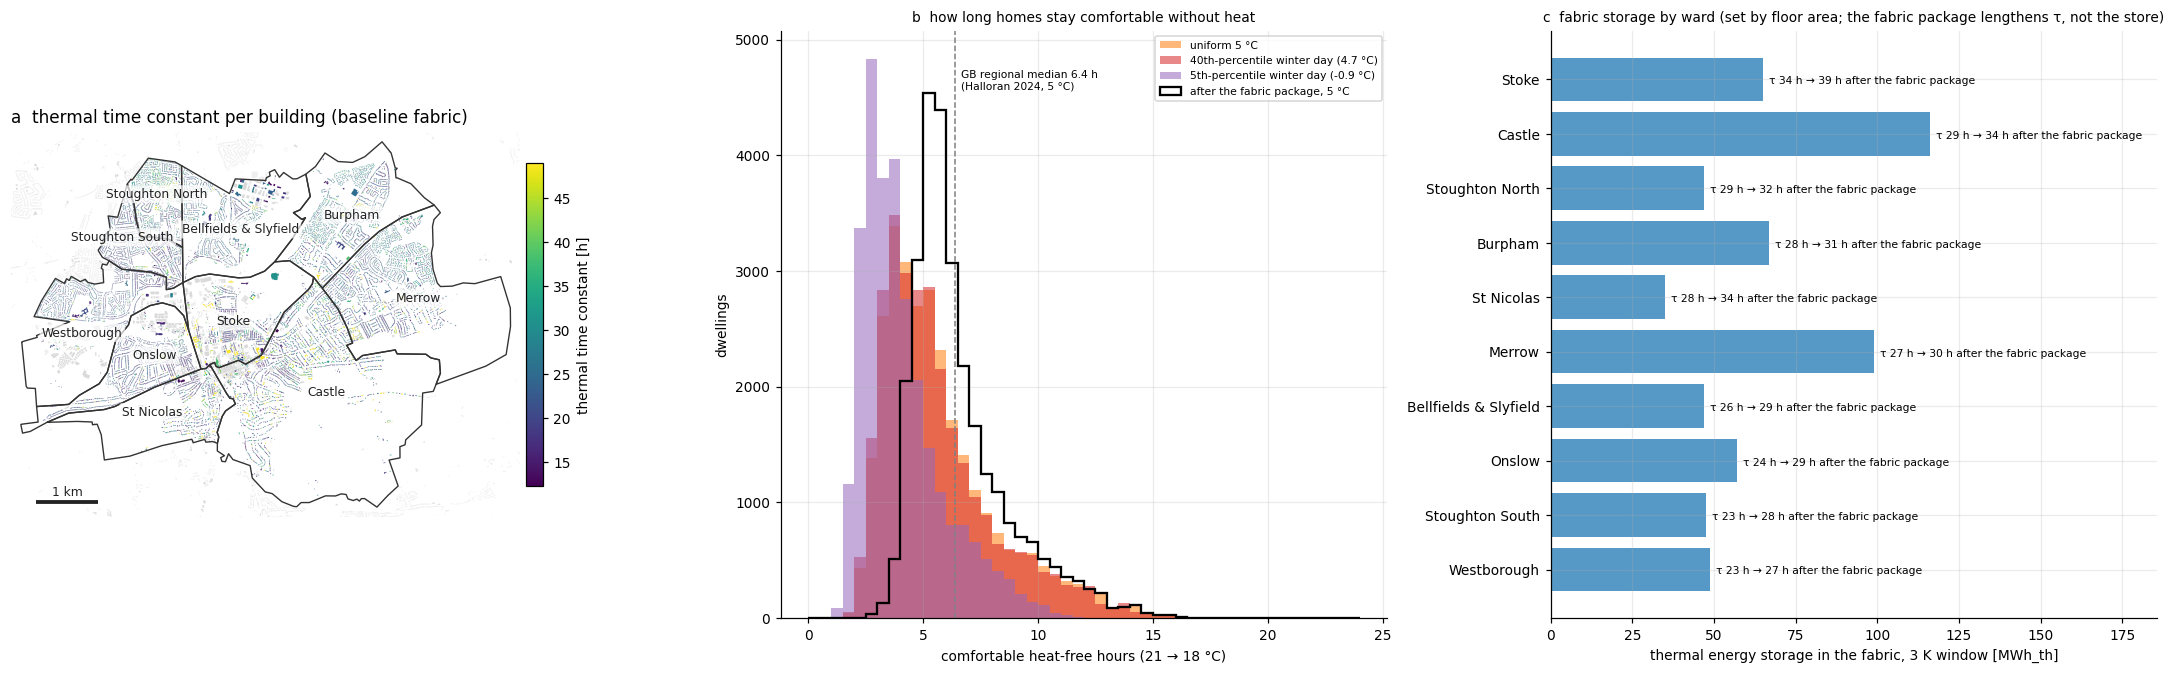

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
maps.base_map(axes[0], L); maps.building_map(axes[0], L, maps.per_building(flex0["time_constant_h"].clip(upper=flex0["time_constant_h"].quantile(0.98)), urban), cmap="viridis", label="thermal time constant [h]"); maps.finish(axes[0], L, title="a  thermal time constant per building (baseline fabric)")
cols = [f"heat_free_hours_at_{ref_t:g}C", "heat_free_hours_p40", "heat_free_hours_p5"]; labs = [f"uniform {ref_t:g} °C", f"40th-percentile winter day ({wt['p40']:.1f} °C)", f"5th-percentile winter day ({wt['p5']:.1f} °C)"]
for c, lab, col in zip(cols, labs, ["tab:orange", "tab:red", "tab:purple"]):
    axes[1].hist(flex0[c].clip(upper=24), bins=np.arange(0, 24.5, 0.5), alpha=0.55, label=lab, color=col)
axes[1].hist(flexf[f"heat_free_hours_at_{ref_t:g}C_fabric"].clip(upper=24), bins=np.arange(0, 24.5, 0.5), histtype="step", lw=1.5, color="k", label=f"after the fabric package, {ref_t:g} °C")
axes[1].axvline(6.4, color="grey", ls="--", lw=1); axes[1].annotate("GB regional median 6.4 h\n(Halloran 2024, 5 °C)", (6.4, axes[1].get_ylim()[1] * 0.9), fontsize=7, xytext=(4, 0), textcoords="offset points")
axes[1].set_xlabel("comfortable heat-free hours (21 → 18 °C)"); axes[1].set_ylabel("dwellings"); axes[1].set_title("b  how long homes stay comfortable without heat", fontsize=9); axes[1].legend(fontsize=7)
bw = by_ward.sort_values("time_constant_h_mean")
axes[2].barh(bw.index, bw["tes_energy_kWh"] / 1e3, color="tab:blue", alpha=0.75)
for k, (w_, r_) in enumerate(bw.iterrows()): axes[2].annotate(f"τ {r_['time_constant_h_mean']:.0f} h → {r_['time_constant_h_mean_fabric']:.0f} h after the fabric package", (r_["tes_energy_kWh"] / 1e3, k), textcoords="offset points", xytext=(4, -3), fontsize=7)
axes[2].set_xlim(0, bw["tes_energy_kWh"].max() / 1e3 * 1.6); axes[2].set_xlabel("thermal energy storage in the fabric, 3 K window [MWh_th]"); axes[2].set_title("c  fabric storage by ward (set by floor area; the fabric package lengthens τ, not the store)", fontsize=9)
plt.tight_layout(); fig.savefig(FIG_UBEM / "10_flexibility.png", bbox_inches="tight"); plt.show()

## 8 · Dwelling-level run of the study area (optional, all cores)

`URBAN_DIRECT = "sample"` simulates a stratified sample of the study-area stock dwelling by
dwelling with hourly output kept (about 1 h per 3,000 dwellings on 32 cores);
`"full"` runs every dwelling (about 9 h, checkpointed and resumable). The direct run is the
check on the archetype-tier scaling used above (same accounting, same households by seed).

In [18]:
URBAN_DIRECT = "off"          # "off" | "sample" | "full"
N_URBAN_SAMPLE = 3000
if URBAN_DIRECT != "off":
    sel = urban if URBAN_DIRECT == "full" else urban.groupby(["ward", "construction_sa"], group_keys=False).apply(lambda g: g.sample(max(2, int(round(N_URBAN_SAMPLE * len(g) / len(urban)))), random_state=SEED))
    ckpt = UBEM_OUT / f"10_stock_urban_{URBAN_DIRECT}.parquet"
    res = simulate_stock(sel, str(EPW), str(PBE_SRC), A_cal, checkpoint=ckpt, n_jobs=N_JOBS, chunk_size=20, stochastic=True, seed=SEED, post=post, resume=True, verbose=0, keep_hourly=True)
    res = res.set_index("dwelling_id").join(inputs[["construction_sa", "size_class", "ward", "LSOA"]]); res.to_parquet(UBEM_OUT / f"10_stock_urban_{URBAN_DIRECT}_joined.parquet")
    tier = _stock_delivered(inputs.loc[res.index], inten_cal, post).set_index("dwelling_id")
    cmp = pd.DataFrame({"direct_GWh": res.groupby("ward")["Q_H_kWh"].sum() / 1e6, "tier_GWh": tier.join(res[["ward"]]).groupby("ward")["Q_H_kWh"].sum() / 1e6}); cmp["tier/direct"] = cmp["tier_GWh"] / cmp["direct_GWh"]
    ids, Qd = profiles.stack_hourly(ckpt.parent / (ckpt.stem + "_hourly")); print(f"direct run: {len(res):,} dwellings, hourly arrays {Qd.shape}"); print(cmp.round(2))
else:
    print("direct urban run switched off (set URBAN_DIRECT to 'sample' or 'full')")

direct urban run switched off (set URBAN_DIRECT to 'sample' or 'full')


## What is in `outputs/ubem/`

* `10_scenario_summary.csv`, `10_scenario_by_ward.csv`, `10_scenario_<U*>.parquet` — the six scenarios on the calibrated tier, per dwelling and per ward;
* `10_low_hanging_fruit_U5.csv`, `10_low_hanging_fruit_groups.csv` — the benefit/cost ranking and its A–F groups;
* `10_carbon_trajectory_kt.csv` — the grid-trajectory view;
* `10_ward_peaks.csv`, `10_tenward_hourly_elec_MW.csv`, `10_tenward_hourly_gas_heat_MW.csv`, `10_peak_method_comparison.csv`, `10_substation_cells.csv`, `10_representative_hourly_fabric.npz` — peaks (heat-pump households after Watson 2021, COP after Ruhnau / Halloran), the hourly study-area profiles and the method comparison;
* `10_flexibility_dwellings.parquet`, `10_flexibility_by_ward.csv` — building-fabric heating flexibility (Halloran 2024);
* figures `10_scenarios_by_ward.png`, `10_maps_scenarios.png`, `10_low_hanging_fruit.png`, `10_map_low_hanging_fruit.png`, `10_carbon_trajectory.png`, `10_heat_pump_shape.png`, `10_peaks.png`, `10_peaks_map.png`, `10_substation_cells.png`, `10_flexibility.png`.